In [37]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
import matplotlib.gridspec as gridspec


from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate


from numpy import log10, exp
from DATA_CHECK import *

kpc = const.kpc.cgs.value

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

nu_Lya_K = c_cms / Ly_a_K
nu_Lya_H = c_cms / Ly_a_H

nu_CIV_K = c_cms / C_IV_K 
nu_CIV_H = c_cms / C_IV_H

Ryd_Lya_K = h_ev * nu_Lya_K / 13.6 
Ryd_Lya_H = h_ev * nu_Lya_H / 13.6 

Ryd_CIV_K = h_ev * nu_CIV_K / 13.6 
Ryd_CIV_H = h_ev * nu_CIV_H / 13.6 




In [38]:

Lumin =44.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_1 = 1 # 1 "" and  2 "no line transfer"
idx_2 = 2
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0

In [39]:
cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

# cloudy_path_1

In [40]:

cloudy_data_1 = CLOUDY_data_path(cloudy_path_1)
cloudy_data_2 = CLOUDY_data_path(cloudy_path_2)

print('--'*50)
print(f"Lya Luminosity = {cloudy_data_2[f'Lumin_Lya']:.2e} [erg/s]")

print('--'*50)
print(f"C IV Luminosity = {cloudy_data_2[f'Lumin_CIV']:.2e} [erg/s]")
print(f"HeII Luminosity = {cloudy_data_2[f'Lumin_HeII']:.2e} [erg/s]")
print('--'*50)
print(f"C IV Column_density = {cloudy_data_2[f'Column_density_CIV']:.2e} [cm-2]")
print(f"He II Column_density = {cloudy_data_2[f'Column_density_HeII']:.2e} [cm-2]")
print('--'*50)

----------------------------------------------------------------------------------------------------
Lya Luminosity = 4.30e+43 [erg/s]
----------------------------------------------------------------------------------------------------
C IV Luminosity = 1.90e+42 [erg/s]
HeII Luminosity = 1.00e+42 [erg/s]
----------------------------------------------------------------------------------------------------
C IV Column_density = 3.59e+17 [cm-2]
He II Column_density = 2.50e+20 [cm-2]
----------------------------------------------------------------------------------------------------


Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.50e-01
Continuum = 6.00e+40 erg/s/A
Peak = 1.11e+41 erg/s/A
velocity dispersion = 3.00e+03 km/s
lmabda_c = 1546.147079489674 A
Equivalent Width = 23.32 Angstrom
Total Luminosity of QSO C IV = 1.40e+42 erg/s
Total Luminosity of Continuum at 1500-1600 A = 6.00e+42 erg/s


Text(0, 0.5, '$L_{\\lambda}~[\\rm erg \\, s^{-1} \\, \\AA^{-1}]$')

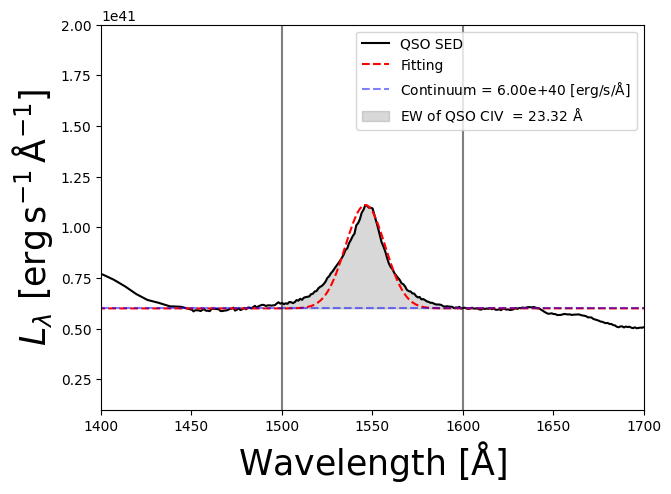

In [41]:

def Flux(Fc,F_max,lam,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / (del_lam**2)) + Fc
    return Flux
def EW(Fc,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    print(f'Del Lambda = {del_lam*1e8:.1f} Angstrom')
    # print('dlam',del_lam)
    EW =abs((F_max - Fc)/ Fc)*np.sqrt(np.pi)*del_lam  # dimension of lambda
    print(f'ratio of Peak and Continuum = {abs((F_max - Fc)/ Fc):.2e}')
    return EW

def Ryd_to_lam(Ryd_x):
    lambda_x = c_cms /  (Ryd_x * 13.6 /h_ev) *1e8


Ryd, Fnu = QSO_SED(cloudy_path_2) # [1/Hz]
nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
nuFnu = Fnu * nu # dimenionless parameter 

normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s


fig = plt.figure(1,figsize=(7,5))

# plt.subplot(121)
Lnu = Fnu*normalized_factor # erg/s/Hz
nuLnu = Fnu*normalized_factor*nu # erg/s

lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A




Lc = 6e40  # erg/s/A
aa = np.argmax(Llambda[ii])
Llambda_max = Llambda[ii[aa]] 
lambda_c = lambda_cm[ii[aa]]
# print(lambda_c)
# lambda_c =(C_IV_K + C_IV_H)/2
nu_c = c_cms / lambda_cm[ii[aa]] 
# print(Llambda_max )

sig_vel = 3000 #km/s
flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A

CIV_total_flux_QSO = ew*Lc #* nu_c
Lc_total_flux_QSO = Lc*   (1600-1500) # erg/s #[min:max] of continuum


print(f'Continuum = {Lc:.2e} erg/s/A') 
print(f'Peak = {Llambda_max:.2e} erg/s/A') 
print(f'velocity dispersion = {sig_vel:.2e} km/s') 
print(f'lmabda_c = {lambda_c*1e8} A') 

print(f'Equivalent Width = {ew:.2f} Angstrom')
print(f'Total Luminosity of QSO C IV = {CIV_total_flux_QSO:.2e} erg/s') 
print(f'Total Luminosity of Continuum at 1500-1600 A = {Lc_total_flux_QSO:.2e} erg/s') 


plt.plot(lambda_A, Llambda,'k-',label='QSO SED')
plt.plot(lambda_A,flux,'r--',label='Fitting')
plt.axhline(y=Lc,xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label=f'Continuum = {Lc:.2e} $\\rm [erg/s/\AA]$')

# Shade area between Lc and Llambda for 1500–1600 Å where Llambda ≥ Lc
m = (lambda_A >= 1500) & (lambda_A <= 1600) & (Llambda >= Lc)
plt.fill_between(lambda_A, Lc, Llambda, where=m, color='gray', alpha=0.3, interpolate=True, label=f'EW of QSO CIV  = {ew:.2f} $\\rm \AA$')

plt.axvline(x=1500,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)
plt.axvline(x=1600,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)

plt.xlim(1400,1700)
plt.ylim(ymin=0.1e41,ymax=2e41)

plt.legend()

plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)


# Llambda_lim = (Llambda[ii] - Lc)
# print(Llambda_lim.sum())

# print((1+0.85)* Lc)

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/QSO_SED', bbox_inches='tight')
# 


In [42]:
# plt.subplot(122)
# Lnu = Fnu*normalized_factor # erg/s/Hz
# nuLnu = Fnu*normalized_factor*nu # erg/s

# lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
# lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

# ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

# Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A




# Lc = 6e40   # erg/s/A
# aa = np.argmax(Llambda[ii])
# Llambda_max = Llambda[ii[aa]] 
# lambda_c = lambda_cm[ii[aa]]
# nu_c = c_cms / lambda_cm[ii[aa]] 
# # print(Llambda_max )

# sig_vel = 3000 #km/s
# flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
# ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A


# print(f'Equivalent Width = {ew:.2f} Angstrom')
# print(f'Total Luminosity = {ew*Lc:.2e} erg/s') 
# CIV_total_flux_QSO = ew*Lc #* nu_c


# # tt = Lc 

# plt.plot(Ryd, Llambda / (c_cms / (lambda_cm)**2 * 1e-8),'k-',label='QSO SED')
# plt.plot(Ryd,flux /  (c_cms / (lambda_cm)**2 * 1e-8) ,'r--',label='Fitting')
# plt.axhline(y=Lc / (c_cms / (lambda_c)**2 * 1e-8),xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label='Continuum')



# plt.xlim(0.5,0.7)

# # plt.yscale('log')
# plt.ylim(ymin=1e28,ymax=2e29)

# plt.legend()

# plt.xlabel(r'Ryd $[ \rm eV]$',fontsize=25)
# plt.ylabel(r'$L_{\nu}~[\rm erg \, s^{-1} \, Hz^{-1}]$',fontsize=25)

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/QSO_CIV_fitting', bbox_inches='tight')

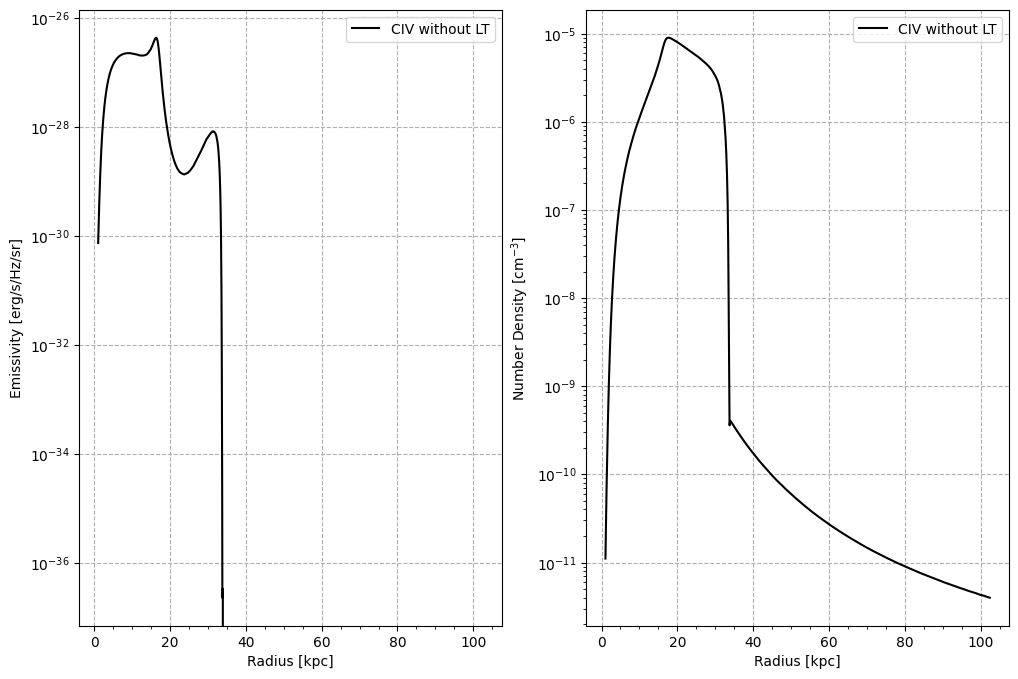

In [43]:
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc
fig= plt.figure(1,figsize=(12,8))
plt.subplot(1,2,1)


atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}_{2}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'emis_{atom}'],'k-',label=f'{atom} without LT')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'], cloudy_data_2[f'frac_CV_{Lum}_{idx_2}'],'r:',label = 'C V')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'], cloudy_data_2[f'frac_CIV_{Lum}_{idx_2}'],'g:',label = 'C IV')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'],cloudy_data_2[f'frac_CIII_{Lum}_{idx_2}'],'b:',label = 'C III')

plt.xlabel('Radius [kpc]')
plt.ylabel('Emissivity [erg/s/Hz/sr]')
plt.yscale('log')
plt.minorticks_on()
plt.grid(True,linestyle='--')

plt.legend()

plt.subplot(1,2,2)
# atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'nden_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'nden_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'nden_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'nden_{atom}'],'k-',label=f'{atom} without LT')
plt.xlabel('Radius [kpc]')
plt.ylabel('Number Density [cm$^{-3}$]')
plt.yscale('log')

plt.minorticks_on()
plt.grid(True,linestyle='--')


plt.legend()


# print(f"HeI Luminosity = {cloudy_data_1[f'Lumin_HeI_{Lumin}_{idx}']:.4e} [erg/s]")

# f'Column_density_CIV_{Lumin}_{idx}'

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/parameter', bbox_inches='tight')

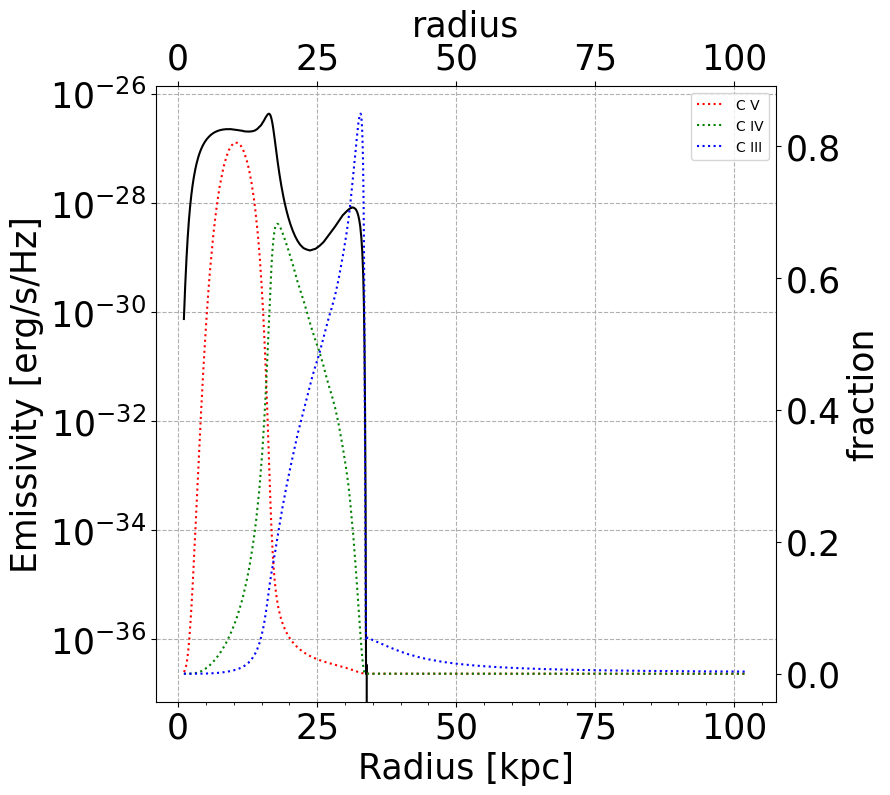

In [44]:
fig= plt.figure(1,figsize=(8,8))

gs = gridspec.GridSpec(1, 1)  #  , width_ratios=[1, 1],  wspace=0.55 

ax1 = fig.add_subplot(gs[0])

atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}_{2}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
ax1.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'emis_{atom}'],'k-',label=f'{atom} without LT')

ax2 = fig.add_axes(ax1.get_position(), frameon=False)

ax2.plot(cloudy_data_2[f'radius'], cloudy_data_2[f'frac_CV'],'r:',label = 'C V')
ax2.plot(cloudy_data_2[f'radius'], cloudy_data_2[f'frac_CIV'],'g:',label = 'C IV')
ax2.plot(cloudy_data_2[f'radius'],cloudy_data_2[f'frac_CIII'],'b:',label = 'C III')

ax1.set_xlabel('Radius [kpc]',fontsize=25)
ax1.set_ylabel('Emissivity [erg/s/Hz]',fontsize=25)
ax1.tick_params(axis='both', labelsize=25)
# ax2.set_ylabel('fraction',fontsize=25)
ax1.set_yscale('log')

ax1.minorticks_on()
ax1.grid(True,linestyle='--')


ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
ax2.set_xlabel('radius', fontsize=25)

ax2.yaxis.set_ticks_position('right')
ax2.yaxis.set_label_position('right')
ax2.set_ylabel('fraction', fontsize=25)
ax2.tick_params(axis='both', labelsize=25)

plt.legend()
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/parameter_fract', bbox_inches='tight')

In [45]:
z_red_shift = 0 
atom = 'CIV'
red_shift_f = (1+z_red_shift)**4
# sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f  #/ sr_to_arc

Lumin = 44.0
V_out = 100 
V_rand = 11.8
V_emit = 100
metals = 1.0
Column_density_order = 22.0

path_RT = "/home/jin/RT/Data_metal"
# style = 'radi'
geo = 'Nebula'
R_path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
# a,b,c = RT_SB(R_path)
# print(a)

In [46]:
Lumin = 44.0
V_out = 100 
V_rand = 11.8
path_RT = "/home/jin/RT/Data_metal"
style = 'radi'
V_out = 500 
geo = 2
V_emit = 100
metals = 1.0
path_test = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
# print(pp)
radius_Ne = RT_SB(path_test)[0]
Num_SB_Ne = RT_SB(path_test)[2]
# Num_SB_Ne
# number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 

Text(0, 0.5, '$\\rm SB(z) x (1+z)^4$ $\\rm [erg \\,s^{-1} \\, cm^{-2}]$ ')

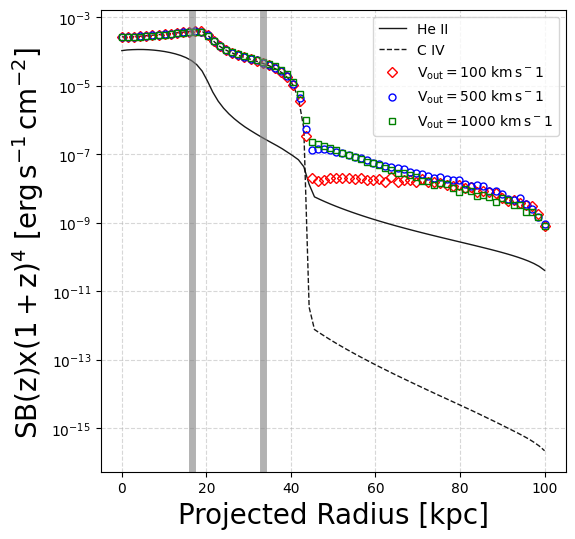

In [47]:
fig = plt.figure(1,figsize=(6,6))

#Common 

z_red_shift = 0 
atom = 'CIV'
red_shift_f = (1+z_red_shift)**4
# sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f  #/ sr_to_arc


path_RT = "/home/jin/RT/Data_metal"


Lumin = 44.0
V_out = 100 
V_rand = 11.8
metals = 0.1
Column_density_order = 22.0


cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

cloudy_data_1 = CLOUDY_data_path(cloudy_path_1)
cloudy_data_2 = CLOUDY_data_path(cloudy_path_2)

#CLOUDY
geo= 'Test'
V_emit = 1.0
# path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_1,metals,Column_density_order)
# print(pp)
# radius_Te_W_LT = RT_SB(path)[0]
# Num_SB_Te_W_LT =RT_SB(path)[2]
# number_dist_W_LT, SB_Te_W_LT = photon_number_SB(radius_Te_W_LT,Num_SB_Te_W_LT,cloudy_data_1[f'Lumin_{atom}_{Lumin}']) 

# path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
# radius_Te_WO_LT = RT_SB(path)[0]/
# Num_SB_Te_WO_LT = RT_SB(path)[2]
# number_dist_WO_LT, SB_Te_WO_LT = photon_number_SB(radius_Te_WO_LT,Num_SB_Te_WO_LT,cloudy_data_2[f'Lumin_{atom}_{Lumin}']) 

radius_Te_W_LT, SB_Te_W_LT = cloudy_data_1[f'radius_p'] , cloudy_data_1[f'SB_{atom}']
radius_Te_WO_LT, SB_Te_WO_LT = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_{atom}']

radius_Te_WO_LT, SB_Te_WO_LT_HeII = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_HeII']

#Nebula
geo = 'Nebula'
V_emit = 3000
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne =  RT_SB(path)[0]
Num_SB_Ne =  RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 


# plt.plot(radius_from_CLOUDY,SB_from_CLOUDY )
# plt.plot(radius_Te_W_LT,SB_Te_W_LT,'k--',label='CLOUDY_W_LT')
plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')
plt.plot(radius_Ne,SB_Ne,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', label=f'$\\rm V_{{\\rm out}} = {V_out}$ $\\rm km \,s^{-1}$') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'

V_out = 500 
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne = RT_SB(path)[0]
Num_SB_Ne = RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
plt.plot(radius_Ne,SB_Ne,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'$\\rm V_{{\\rm out}} = {V_out}$ $\\rm km \,s^{-1}$') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'

V_out = 1000 
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne = RT_SB(path)[0]
Num_SB_Ne = RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
plt.plot(radius_Ne,SB_Ne,marker='s',color='g',linestyle='', markersize=5, markerfacecolor='none', label=f'$\\rm V_{{\\rm out}} = {V_out}$ $\\rm km \,s^{-1}$') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'


# plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO_Gaussian') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

# plt.plot(radius_Ne,SB_Ne + SB_Q,marker='X',color='k',linestyle='', markersize=5, markerfacecolor='none', label=f'Nebula + QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
# plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

plt.yscale('log')

plt.legend()

plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.ylim(ymin=1e-10)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/HERE', bbox_inches='tight')

Text(0, 0.5, '$\\rm SB(z) x (1+z)^4$ $\\rm [erg \\,s^{-1} \\, cm^{-2}]$ ')

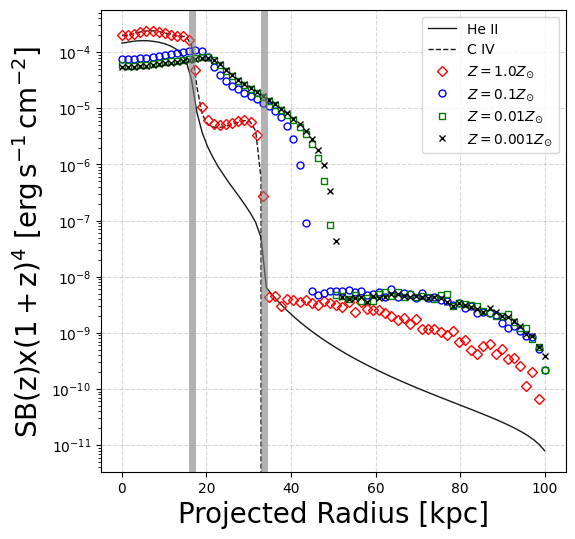

In [48]:
fig = plt.figure(1,figsize=(6,6))

#Common 

z_red_shift = 0 
atom = 'CIV'
red_shift_f = (1+z_red_shift)**4
# sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f  #/ sr_to_arc


path_RT = "/home/jin/RT/Data_metal"


Lumin = 44.0
V_out = 100 
V_rand = 11.8
metals = 1.0
Column_density_order = 22.0


cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

cloudy_data_1 = CLOUDY_data_path(cloudy_path_1)
cloudy_data_2 = CLOUDY_data_path(cloudy_path_2)

#CLOUDY
geo= 'Test'
# V_emit = 1.0
radius_Te_W_LT, SB_Te_W_LT = cloudy_data_1[f'radius_p'] , cloudy_data_1[f'SB_{atom}']
radius_Te_WO_LT, SB_Te_WO_LT = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_{atom}']

radius_Te_WO_LT, SB_Te_WO_LT_HeII = cloudy_data_2[f'radius_p'] , cloudy_data_2[f'SB_HeII']

#Nebula
geo = 'Nebula'
V_emit = 3000
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne =  RT_SB(path)[0]
Num_SB_Ne =  RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 


# plt.plot(radius_from_CLOUDY,SB_from_CLOUDY )
# plt.plot(radius_Te_W_LT,SB_Te_W_LT,'k--',label='CLOUDY_W_LT')
plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',lw=1,alpha=0.9,label='He II')
plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',lw=1,alpha=0.9,label='C IV')
plt.plot(radius_Ne,SB_Ne,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none',label=f'$ Z = {metals} Z_{{\\odot}} $ ') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'

metals = 0.1
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne = RT_SB(path)[0]
Num_SB_Ne = RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
plt.plot(radius_Ne,SB_Ne,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'$ Z = {metals} Z_{{\\odot}} $ ') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'

metals = 0.01
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne = RT_SB(path)[0]
Num_SB_Ne = RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
plt.plot(radius_Ne,SB_Ne,marker='s',color='g',linestyle='', markersize=5, markerfacecolor='none', label=f'$ Z = {metals} Z_{{\\odot}} $ ') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'


metals = 0.001
path = RT_CLOUDY_path(path_RT,V_out, V_emit, V_rand, geo, atom, Lumin,idx_2,metals,Column_density_order)
radius_Ne = RT_SB(path)[0]
Num_SB_Ne = RT_SB(path)[2]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}']) 
plt.plot(radius_Ne,SB_Ne,marker='x',color='k',linestyle='', markersize=5, markerfacecolor='none', label=f'$ Z = {metals} Z_{{\\odot}} $ ') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'


# plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO_Gaussian') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

plt.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
plt.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

# plt.plot(radius_Ne,SB_Ne + SB_Q,marker='X',color='k',linestyle='', markersize=5, markerfacecolor='none', label=f'Nebula + QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
# plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

plt.yscale('log')

plt.legend()

plt.grid(True,linestyle='--',alpha=0.5)

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.ylim(ymin=1e-10)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/HERE', bbox_inches='tight')

Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.50e-01
Lambda, Escape+Scattering Photon Spectrum, Scattering Photon Spectrum 
Lambda, Escape+Scattering Photon Spectrum, Scattering Photon Spectrum 
Lambda, Escape+Scattering Photon Spectrum, Scattering Photon Spectrum 
Total Gaussian of QSO luminosity = 1.40e+42 [erg/s]
Totla Flat of QSO luminosity  = 5.00e+41 [erg/s]
0.6153846153846154


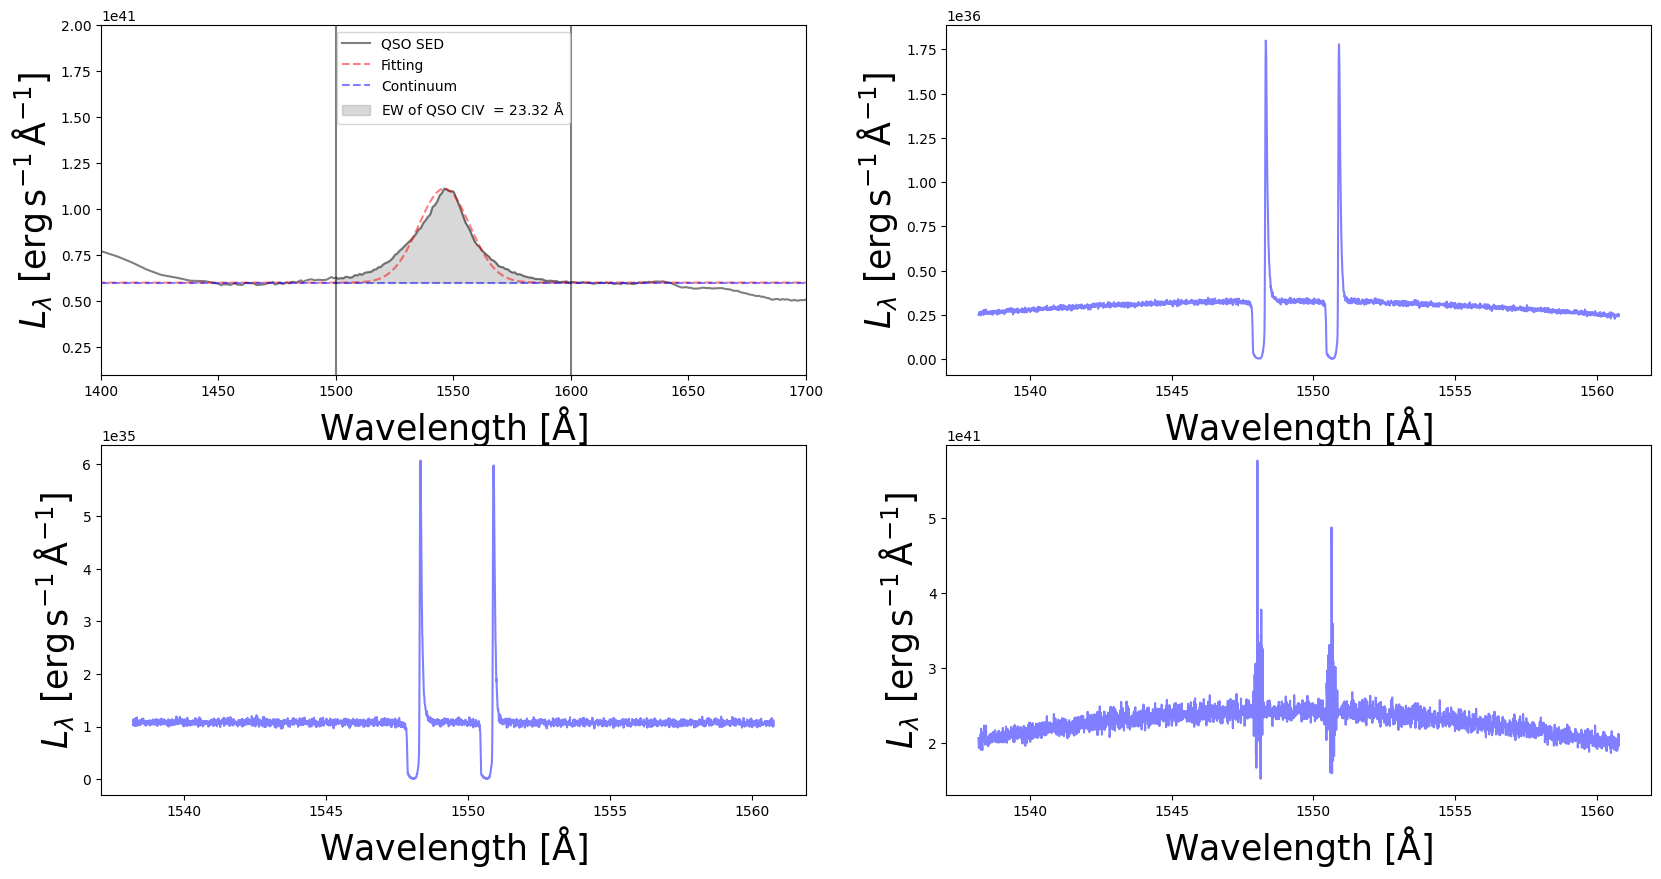

In [49]:
from DATA_CHECK import *

fig = plt.figure(1,figsize=(20,10))

# path_d = '/home/jin/data_CIV'


# ----- Common -----
V_out  = 100
V_emit = 3000
V_rand = 11.8
# ----- Common -----

# ----- Data -----
# atom_num, atom_index = 32 , 15
# path_Data = Data_path(path_d,style, atom_num, atom_index , V_out, V_emit, V_rand)
# print(path_Data)
# ----- Data -----



#------ SB --------

atom = 'CIV'
# path_s = '/home/jin/RT/Data_RT/data'
path_s = "/home/jin/RT/Data_metal"
data_file = 'no'
Lumin = 44.0 
idx = 2
metals = 1.0
Column_density_order = 22.0


V_out  = 100
V_emit = 3000
V_rand = 11.8

path_sed =  CLOUDY_path(Lumin,2,metals,Column_density_order)
Ryd, Fnu = QSO_SED(path_sed) # [1/Hz]
nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
nuFnu = Fnu * nu # dimenionless parameter 

normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s
Lnu = Fnu*normalized_factor # erg/s/Hz
nuLnu = Fnu*normalized_factor*nu # erg/s

lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A


Lc = 6e40  # erg/s/A
aa = np.argmax(Llambda[ii])
Llambda_max = Llambda[ii[aa]] 
lambda_c = lambda_cm[ii[aa]]
# print(lambda_c)
# lambda_c =(C_IV_K + C_IV_H)/2
nu_c = c_cms / lambda_cm[ii[aa]] 
# print(Llambda_max )

sig_vel = 3000 #km/s
flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A

Geometry = 4
path_cont =RT_CLOUDY_path(path_s,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)
lam_cont, spec_tot_cont, spec_sc_cont = spec_com(path_cont)

lam_min = lam_cont.min()
lam_max = lam_cont.max()

plt.subplot(221)

plt.plot(lambda_A, Llambda,'k-',label='QSO SED',alpha=0.5)
plt.plot(lambda_A,flux,'r--',label='Fitting',alpha=0.5)
plt.axhline(y=Lc,xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label='Continuum')

m = (lambda_A >= 1500) & (lambda_A <= 1600) & (Llambda >= Lc)
plt.fill_between(lambda_A, Lc, Llambda, where=m, color='gray', alpha=0.3, interpolate=True, label=f'EW of QSO CIV  = {ew:.2f} $\\rm \AA$')



# 
jj = np.where((lambda_A >= lam_min)& (lambda_A <= lam_max) )
# print(jj)
# plt.plot(lambda_A[jj], Llambda[jj],'b--',label='QSO SED')
# Llambda_lim = (Llambda[jj] - Lc)
# print(Llambda_lim.sum())

# plt.axvline(x=lam_min,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)
# plt.axvline(x=lam_max,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)

# print((Llambda[jj]-flux[jj]).sum())

plt.axvline(x=1500,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)
plt.axvline(x=1600,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)

plt.xlim(1400,1700)
plt.ylim(ymin=0.1e41,ymax=2e41)

plt.legend()

plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)



plt.subplot(222)
Geometry = 3  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
path_qso =RT_CLOUDY_path(path_s,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

lam_qso, spec_tot_qso, spec_sc_qso = spec_com(path_qso)
# plt.plot(lam_cont,spec_tot_cont,'b-',alpha=0.5)


C_IV_total_Gaussian = Lc * ew
factor = C_IV_total_Gaussian / np.sum(spec_tot_qso)
test_qso = spec_tot_qso * factor  / lam_qso  #[erg/s/A]


plt.plot(lam_qso,test_qso,'b-',alpha=0.5)

plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)


plt.subplot(223)
Geometry = 4 # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
path_cont =RT_CLOUDY_path(path_s,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

lam_cont, spec_tot_cont, spec_sc_cont = spec_com(path_cont)
# plt.plot(lam_cont,spec_tot_cont,'b-',alpha=0.5)

# C_IV_total_Flat =  Lc * (1600-1500)  #(lam_cont.max()-lam_cont.min()) 
C_IV_total_Flat = 0.5e42
factor = C_IV_total_Flat   / np.sum(spec_tot_cont)
test_cont = spec_tot_cont * factor / lam_cont  #[erg/s/A]

plt.plot(lam_cont,test_cont,'b-',alpha=0.5)
plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)



plt.subplot(224)

# y = spec_tot_cont + spec_tot_qso

ff = (test_cont+test_qso) / test_cont
y= ff*Lc
plt.plot(lam_cont,y,'b-',alpha=0.5)

# print(f'Total_Lum = {y.sum():.2e}')
print(f'Total Gaussian of QSO luminosity = {C_IV_total_Gaussian:.2e} [erg/s]')
print(f'Totla Flat of QSO luminosity  = {C_IV_total_Flat:.2e} [erg/s]')
plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)

# print(Llambda_max)



# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/paramete', bbox_inches='tight')

print((2.1-1.3)/1.3)

In [50]:
# from DATA_CHECK import *

# def EW(Fc,F_max,lam_c,sig_vel):
#     del_lam = sig_vel / c_kms  * lam_c
#     print(f'Del Lambda = {del_lam*1e8:.1f} Angstrom')
#     # print('dlam',del_lam)
#     EW =abs((F_max - Fc)/ Fc)*np.sqrt(np.pi)*del_lam  # dimension of lambda
#     print(f'ratio of Peak and Continuum = {abs((F_max - Fc)/ Fc):.2e}')
#     return EW


# Geometry = 3  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = Flat, 5 = AGN_con
# atom = 'CIV'
# path_s = '/home/jin/RT/Data_RT/data'
# data_file = 'no'
# Lumin = 44.0 
# idx = 2
# metals = 1.0
# Column_density_order = 22.0

# V_out  = 500
# V_rand = 11.8

# lam_min = lam_cont.min()
# lam_max = lam_cont.max()

# fig = plt.figure(1,figsize=(16,8))

# Lnu = Fnu*normalized_factor # erg/s/Hz
# nuLnu = Fnu*normalized_factor*nu # erg/s

# lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
# lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

# ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

# Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A




# Lc = 6e40  # erg/s/A
# aa = np.argmax(Llambda[ii])
# Llambda_max = Llambda[ii[aa]] 
# lambda_c = lambda_cm[ii[aa]]
# # print(lambda_c)
# # lambda_c =(C_IV_K + C_IV_H)/2
# nu_c = c_cms / lambda_cm[ii[aa]] 
# # print(Llambda_max )

# sig_vel = 3000 #km/s
# flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
# ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A

# CIV_total_flux_QSO = ew*Lc #* nu_c
# # Lc_total_flux_QSO = Lc*(1600-1500) 
# Lc_total_flux_QSO =  5e41 #Lc*(1600-1500) 
# CIV_Lumin = cloudy_data_2[f'Lumin_{atom}_{Lumin}']
# plt.subplot(121)

# #CLOUDY
# Geometry_Te = 'Test'
# V_emit_Te = 1.0
# radius_Te_W_LT = RT_make_parameter(z_red_shift,V_out, V_emit_Te, V_rand, Geometry_Te, atom, Lumin,idx_1,metals,Column_density_order)[0]
# Num_SB_Te_W_LT = RT_make_parameter(z_red_shift,V_out, V_emit_Te, V_rand, Geometry_Te, atom, Lumin,idx_1,metals,Column_density_order)[3]
# # number_dist_W_LT, SB_Te_W_LT = photon_number_SB(radius_Te_W_LT,Num_SB_Te_W_LT,cloudy_data_1[f'Lumin_{atom}_{Lumin}']) 

# radius_Te_WO_LT = RT_make_parameter(z_red_shift,V_out, V_emit_Te, V_rand, Geometry_Te, atom, Lumin,idx_2,metals,Column_density_order)[0]
# Num_SB_Te_WO_LT = RT_make_parameter(z_red_shift,V_out, V_emit_Te, V_rand, Geometry_Te, atom, Lumin,idx_2,metals,Column_density_order)[3]
# # number_dist_WO_LT, SB_Te_WO_LT = photon_number_SB(radius_Te_WO_LT,Num_SB_Te_WO_LT,cloudy_data_2[f'Lumin_{atom}_{Lumin}']) 

# radius_Te_W_LT, SB_Te_W_LT = cloudy_data_1[f'radius_p_{Lumin}'] , cloudy_data_1[f'SB_{atom}_{Lumin}']
# radius_Te_WO_LT, SB_Te_WO_LT = cloudy_data_2[f'radius_p_{Lumin}'] , cloudy_data_2[f'SB_{atom}_{Lumin}']

# radius_Te_WO_LT, SB_Te_WO_LT_HeII = cloudy_data_2[f'radius_p_{Lumin}'] , cloudy_data_2[f'SB_HeII_{Lumin}']

# #Nebula
# Geometry = 2 # 'Nebula'
# V_emit = 3000 
# path =RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)
# number_dist_Ne, SB_Ne = photon_number_SB(RT_SB(path)[0],RT_SB(path)[2],cloudy_data_2[f'Lumin_{atom}_{Lumin}']) 
# radius_Ne = RT_SB(path)[0]
# #QSO
# Geometry = 3 # 'Nebula'
# V_emit = 3000 
# path =RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)
# number_dist_Q, SB_Q = photon_number_SB(RT_SB(path)[0],RT_SB(path)[2],CIV_total_flux_QSO) 
# radius_Q = RT_SB(path)[0]
# #Flat
# Geometry = 4 # 'Flat or Continuum'
# V_emit = 3000 
# path =RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)
# number_dist_Cont, SB_Cont = photon_number_SB(RT_SB(path)[0],RT_SB(path)[2],Lc_total_flux_QSO) 
# radius_Cont = RT_SB(path)[0]



# print(f'Total Luminosity of Gaussian = {CIV_total_flux_QSO:.2e} erg/s') 
# print(f'Total Luminosity of Continuum at 1500-1600 A = {Lc_total_flux_QSO:.2e} erg/s') 
# print(f'Total Luminosity of CIV_CLOUDY = {CIV_Lumin:.2e} erg/s') 
# print(f'Equivalent Width = {ew:.2f} A')

# # plt.plot(radius_from_CLOUDY,SB_from_CLOUDY )
# # plt.plot(radius_Te_W_LT,SB_Te_W_LT,'k--',label='CLOUDY_W_LT')
# plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',label='CLOUDY He II')
# plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',label='CLOUDY C IV')
# plt.plot(radius_Ne,SB_Ne,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', label=f'Nebula') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
# plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'Gaussian') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$
# plt.plot(radius_Cont,SB_Cont,marker='X',color='y',linestyle='', markersize=5, markerfacecolor='none', label=f'Continuum') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

# QSO_SB = SB_Q + SB_Cont

# # plt.plot(radius_Cont,QSO_SB ,marker='p',color='g',linestyle='', markersize=10, markerfacecolor='none', label=f'QSO')

# # plt.plot(radius_Ne,SB_Ne + SB_Q,marker='X',color='k',linestyle='', markersize=5, markerfacecolor='none', label=f'Nebula + QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
# # plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

# plt.yscale('log')

# plt.legend()

# plt.xlabel('Projected Radius [kpc]', fontsize=20)
# plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# # plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_result_SB', bbox_inches='tight')

# plt.subplot(122)

# plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',label='CLOUDY He II')
# plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',label='CLOUDY C IV')
# plt.plot(radius_Ne,SB_Ne,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', label=f'Nebula') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
# # plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'Gaussian') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$
# # plt.plot(radius_Cont,SB_Cont,marker='X',color='y',linestyle='', markersize=5, markerfacecolor='none', label=f'Continuum') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

# QSO_SB = SB_Q + SB_Cont

# plt.plot(radius_Cont,QSO_SB ,marker='p',color='g',linestyle='', markersize=10, markerfacecolor='none', label=f'QSO')
# plt.yscale('log')

# plt.legend()

# plt.xlabel('Projected Radius [kpc]', fontsize=20)
# plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)

# # plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/result_qso_nebula_1', bbox_inches='tight')


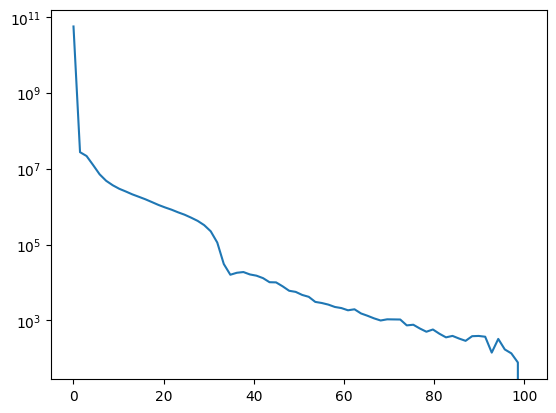

In [51]:
from DATA_CHECK import *

Geometry = 3  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
atom = 'CIV'
path_s = '/home/jin/RT/RT_scat'
data_file = 'CLOUDY'
Lumin = 44.0 
idx = 2
metals = 1.0
Column_density_order = 22.0

V_out  = 500 
V_emit = 3000
V_rand = 11.8

path_SB =RT_CLOUDY_path(path_s,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)
radius_CIV, SB_CIV = RT_SB(path_SB)[0], RT_SB(path_SB)[2]

plt.plot(radius_CIV,SB_CIV)
plt.yscale('log')


Del Lambda = 15.5 Angstrom
ratio of Peak and Continuum = 8.50e-01


TypeError: RT_CLOUDY_path() takes 10 positional arguments but 11 were given

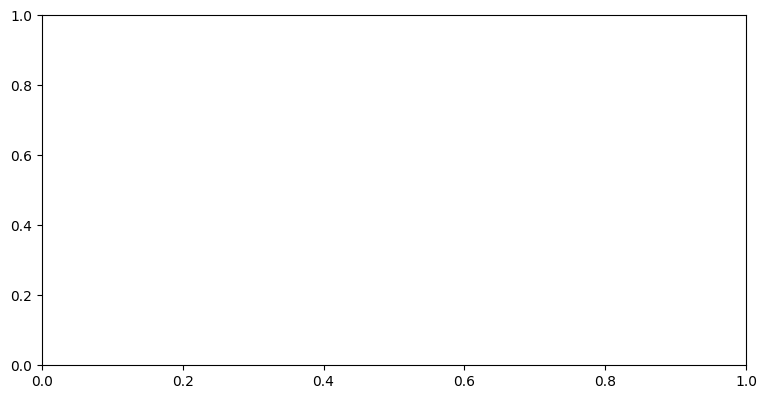

In [ ]:
# from DATA_CHECK import *

# fig = plt.figure(1,figsize=(20,10))

# # path_d = '/home/jin/data_CIV'


# # ----- Common -----
# V_out  = 100
# V_emit = 3000
# V_rand = 11.8
# # ----- Common -----

# # ----- Data -----
# # atom_num, atom_index = 32 , 15
# # path_Data = Data_path(path_d,style, atom_num, atom_index , V_out, V_emit, V_rand)
# # print(path_Data)
# # ----- Data -----



# #------ SB --------

# atom = 'CIV'
# path_s = '/home/jin/RT/Data_RT/data'
# data_file = 'no'
# Lumin = 44.0 
# idx = 2
# metals = 1.0
# Column_density_order = 22.0


# V_out  = 100
# V_emit = 3000
# V_rand = 11.8

# path_sed =  CLOUDY_path(Lumin,2,metals,Column_density_order)
# Ryd, Fnu = QSO_SED(path_sed) # [1/Hz]
# nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
# nuFnu = Fnu * nu # dimenionless parameter 

# normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s
# Lnu = Fnu*normalized_factor # erg/s/Hz
# nuLnu = Fnu*normalized_factor*nu # erg/s

# lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
# lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

# ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

# Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A




# Lc = 6e40  # erg/s/A
# aa = np.argmax(Llambda[ii])
# Llambda_max = Llambda[ii[aa]] 
# lambda_c = lambda_cm[ii[aa]]
# # print(lambda_c)
# # lambda_c =(C_IV_K + C_IV_H)/2
# nu_c = c_cms / lambda_cm[ii[aa]] 
# # print(Llambda_max )

# sig_vel = 3000 #km/s
# flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
# ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A


# plt.subplot(221)
# Geometry = 3  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
# path_qso =RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

# lam_qso, spec_tot_qso, spec_sc_qso = spec_com(path_qso)
# # plt.plot(lam_cont,spec_tot_cont,'b-',alpha=0.5)


# C_IV_total_Gaussian = Lc * ew
# factor = C_IV_total_Gaussian / np.sum(spec_tot_qso)
# test_qso = spec_tot_qso  #* factor  / lam_qso  #[erg/s/A]


# plt.plot(lam_qso,test_qso,'b-',alpha=0.5,label='Gaussian')

# plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
# plt.ylabel(r'Photon',fontsize=25)

# plt.legend()

# plt.subplot(222)
# Geometry = 4 # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
# path_cont =RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

# lam_cont, spec_tot_cont, spec_sc_cont = spec_com(path_cont)
# # plt.plot(lam_cont,spec_tot_cont,'b-',alpha=0.5)

# C_IV_total_Flat =  Lc * (1600-1500) #(lam_cont.max()-lam_cont.min()) 
# factor = C_IV_total_Flat   / np.sum(spec_tot_cont)
# test_cont = spec_tot_cont #* factor / lam_cont  #[erg/s/A]

# plt.plot(lam_cont,test_cont,'k-',alpha=0.5,label='Flat')
# plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
# # plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)

# plt.legend()
# plt.ylabel(r'Photon',fontsize=25)

# plt.subplot(223)

# # y = spec_tot_cont + spec_tot_qso
# y= test_cont + test_qso
# plt.plot(lam_cont,y,'r-',alpha=0.5,label='QSO')
# plt.plot(lam_qso,test_qso,'b-',alpha=0.5,label='Gaussian')
# plt.plot(lam_cont,test_cont,'k-',alpha=0.5,label='Flat')


# print(f'Total Gaussian of QSO luminosity = {C_IV_total_Gaussian:.2e} [erg/s]')
# print(f'Totla Flat of QSO luminosity  = {C_IV_total_Flat:.2e} [erg/s]')
# plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
# plt.ylabel(r'Photon',fontsize=25)

# plt.legend()
# # print(Llambda_max)

# plt.subplot(224)

# plt.plot(lambda_A, Llambda,'k-',label='QSO SED')
# plt.plot(lambda_A,flux,'r--',label='Fitting')
# plt.axhline(y=Lc,xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label='Continuum')
# # 
# lam_min = lam_cont.min()
# lam_max = lam_cont.max()

# plt.axvline(x=lam_min,ymin=0,ymax=1,linestyle='-',color='b',alpha=0.5)
# plt.axvline(x=lam_max,ymin=0,ymax=1,linestyle='-',color='b',alpha=0.5)

# plt.axvline(x=1500,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)
# plt.axvline(x=1600,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)

# plt.xlim(1400,1700)
# plt.ylim(ymin=0.1e41,ymax=2e41)

# plt.legend()

# plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
# plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)

# # plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/paramete', bbox_inches='tight')

# print((6.4-2.9)/2.9)

In [ ]:
# from CLOUDY_Function import *

# def Flux(Fc,F_max,lam,lam_c,sig_vel):
#     del_lam = sig_vel / c_kms  * lam_c
#     Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / (del_lam**2)) + Fc
#     return Flux
# def EW(Fc,F_max,lam_c,sig_vel):
#     del_lam = sig_vel / c_kms  * lam_c
#     print(f' Del Lambda = {del_lam*1e8:.1f} Angstrom')
#     # print('dlam',del_lam)
#     EW =(F_max / Fc)*np.sqrt(np.pi)*del_lam  # dimension of lambda
#     return EW

# def Ryd_to_lam(Ryd_x):
#     lambda_x = c_cms /  (Ryd_x * 13.6 /h_ev) *1e8


# Ryd, Fnu = QSO_SED(path = path(Lumin,2,metals,Column_density_order)) # [1/Hz]
# nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
# nuFnu = Fnu * nu # dimenionless parameter 

# normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s


# fig = plt.figure(1,figsize=(7,5))

# # plt.subplot(121)
# Lnu = Fnu*normalized_factor # erg/s/Hz
# nuLnu = Fnu*normalized_factor*nu # erg/s




# lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
# lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

# ii = np.where((lambda_cm >1500e-8) & (lambda_cm <= 1600e-8))[0]

# Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A





# Lc = 6e40  # erg/s/A
# aa = np.argmax(Llambda[ii])
# Llambda_max = Llambda[ii[aa]] 
# lambda_c = lambda_cm[ii[aa]]
# # lambda_c =(C_IV_K + C_IV_H)/2
# nu_c = c_cms / lambda_cm[ii[aa]] 
# # print(Llambda_max )

# sig_vel = 3000 #km/s
# flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
# ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A


# print(f'Continuum = {Lc:.2e} erg/s/A') 
# print(f'Peak = {Llambda_max:.2e} erg/s/A') 
# print(f'velocity dispersion = {sig_vel:.2e} km/s') 
# print(f'lmabda_c = {lambda_c*1e8} A') 

# print(f'Equivalent Width = {ew:.2f} Angstrom')
# print(f'Total Luminosity = {ew*Lc:.2e} erg/s') 

# CIV_total_flux_QSO = ew*Lc #* nu_c
# Lc_total_flux_QSO = Lc*(1600-1500) # erg/s #[min:max] of continuum


# plt.plot(lambda_A, Llambda,'k-',label='QSO SED')
# plt.plot(lambda_A,flux,'r--',label='Fitting')
# plt.axhline(y=Lc,xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label='Continuum')

# plt.axvline(x=lam_min,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)
# plt.axvline(x=lam_max,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.5)

# plt.xlim(1400,1700)
# plt.ylim(ymin=0.1e41,ymax=2e41)

# plt.legend()

# plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
# plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)

# print(np.sum(Llambda[ii]), Lc*ew, Lc*75)

1.0010511456875975
1.400245332847214e+42
23.33742221412023
1.546147079489674e-05
 Del Lambda = 15.5 Angstrom
1.3993663870879777e+42


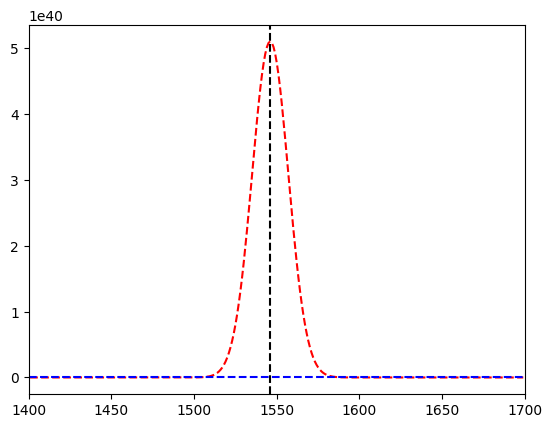

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d
# def Flux(Fc,F_max,lam,lam_c,sig_vel):
#     del_lam = sig_vel / c_kms  * lam_c
#     Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / (del_lam**2)) + Fc
#     return Flux

# idx = np.argsort(lambda_A)
# lam = lambda_A[idx]
# spec = flux[idx]

# y = spec - Lc
# lam_min,lam_max = 1400,1700
# m = (lam >= lam_min) & (lam <= lam_max)


# plt.plot(lam[m],y[m],'r--',label='Fitting')
# dlam = abs(lambda_A[ii[aa]] -lambda_A[ii[aa]+1])
# print(dlam) 
# # print(y.max(), Llambda_max - Lc)
# print(y[m].sum()*dlam)

# total = y[m].sum()*dlam
# print(total/Lc)

# plt.axhline(y=0,xmin=0,xmax=1,linestyle='--',color='b')
# plt.axvline(x=lambda_c*1e8,ymin=0,ymax=1,linestyle='--',color='k')
# lambda_c = lambda_cm[ii[aa]]
# print(lambda_c)
# plt.xlim(1400,1700)
# # plt.ylim(ymin=0.1e41,ymax=2e41)

# def EW(Fc,F_max,lam_c,sig_vel):
#     del_lam = sig_vel / c_kms  * lam_c
#     print(f' Del Lambda = {del_lam*1e8:.1f} Angstrom')
#     # print('dlam',del_lam)
#     EW =(F_max / Fc)*np.sqrt(np.pi)*del_lam  # dimension of lambda
#     return EW

# ew = EW(Lc, y.max(), lambda_c,3000)
# print(ew*1e8*Lc)

In [ ]:
# V_out  = 0
# V_emit = 3000
# V_rand = 0
# Geometry = 4  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
# atom = 'CIV'
# path_s = '/home/jin/RT/Data_RT_dlam_50/flat_data'
# data_file = 'SB'
# path_SB = RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

# lam, spec_tot, spec_sc = spec_com(path_SB)
# print(f'{np.sum(spec_tot):.2e}')
# plt.plot(lam,spec_tot/np.sum(spec_tot),'b-',alpha=0.5)




# ii = np.argmax(spec_tot)
# plt.scatter(lam[ii],spec_tot[ii],s=30,color='k')

# max_flux = spec_tot[ii]/2
# for jj , kk in enumerate(lam):
#     if spec_tot[jj] >=  max_flux and spec_tot[jj+1] <=  max_flux:
#         print(jj)


# plt.scatter(lam[963],spec_tot[963],s=30,color='r')
# plt.scatter(lam[2006],spec_tot[2006],s=30,color='r')

# # delV = (abs(lam[963] - lam[ii]) / lam[ii]) *c_kms
# FWHM = abs(lam[1758]- lam[ii])*2
# print(FWHM/2.35)
# # Geometry = 1

# path_SB = RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

# lam, spec_tot, spec_sc = spec_com(path_SB)
# print(f'{np.sum(spec_tot):.2e}')
# plt.plot(lam,spec_tot/np.sum(spec_tot),'k--')

# ff = spec_tot/np.sum(spec_tot)
# flux_a = (flux-Lc)/np.sum(flux) 
# factor = flux_a.max() / ff.max()
# plt.plot(lambda_A,(flux-Lc)/np.sum(flux) ,'r--',label='Fitting')
# plt.plot(lam,ff*factor,'b-',alpha=0.5)
# plt.xlim(1450,1650)
# plt.yscale('log')

In [ ]:
# path_s = '/home/jin/RT/Data_RT_dlam_50/flat_data'
# data_file = 'SB'
# V_out  = 0
# V_emit = 3000
# V_rand = 0
# Geometry = 4  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat

# path_SB = RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

# lam_cont, spec_tot_cont, spec_sc_cont = spec_com(path_SB)

# plt.plot(lam_cont,spec_tot_cont,'b-',alpha=0.5)


# Geometry = 3  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
# atom = 'CIV'
# path_s = '/home/jin/RT/RT_scat'
# data_file = 'CLOUDY'
# Lumin = 44.0 
# idx = 2
# metals = 1.0
# Column_density_order = 22.0

# V_out  = 500 
# V_emit = 3000
# V_rand = 11.8

# path_SB =RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

# lam_gau, spec_tot_gau, spec_gau = spec_com(path_SB)

# plt.plot(lam_gau, spec_tot_gau)


In [ ]:
# path_s = '/home/jin/RT/Data_RT_dlam_50/flat_data'
# data_file = 'SB'
# V_out  = 0
# V_emit = 3000
# V_rand = 0
# Geometry = 4  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat

# path_SB = RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

# # print(path_SB)

# radius_CIV, SB_CIV = RT_SB(path_SB)[0], RT_SB(path_SB)[2]

# plt.plot(radius_CIV,SB_CIV)
# # print(SB_CIV[])
# plt.yscale('log')